In [9]:
# Aluno: Nicholas Barbosa e Costa
# Matrícula: 95667

from torch.utils.data import DataLoader, random_split #empacotamento de dados e divisão do dataset
import torchvision  

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchinfo import summary

from torch.utils.tensorboard import SummaryWriter

import torch.optim 

from tqdm import tqdm

import copy
  
from datetime import datetime

import PIL

import random

SEED = 95667


np.random.seed(SEED)
torch.manual_seed(SEED)

# Se estiver usando GPU Apple (MPS):
torch.mps.manual_seed(SEED)

# Dados

## Caminhos

In [2]:
datasets_path     = '/Users/nicholasbarbosa/Mestrado/inf692/atividade-curta-5/datasets/'
models_path       = '/Users/nicholasbarbosa/Mestrado/inf692/atividade-curta-5/models/'
tensorboard_path  = '/Users/nicholasbarbosa/Mestrado/inf692/atividade-curta-5/Tensorboard/2026_1/lenet5/'

## Dataloader

In [42]:
def my_imshow(img, dataset, numImages=10):
  
    if dataset == 'cifar10' : 
        img = img / 2 + 0.5     # unnormalize
    
    img = torchvision.utils.make_grid(img[:numImages],nrow=numImages//2)
    
    npimg = img.numpy()    
    npimg = np.transpose(npimg, (1, 2, 0))
    
    plt.axis('off')
    plt.imshow(npimg)
    plt.show()

def show_images(data_loader, dataset, numImages=10) :
    print(f"Train samples, {data_loader['train']['length']}")
    # get some random training images
    dataiter = iter(data_loader['train']['data']) #cria um iterador a partir do DataLoader
    images = next(dataiter)[0] # pega o primeiro batch de imagens/labels e retorna apenas as imagens (índice 0, pois o segundo índice seria os rótulos)
    my_imshow(images, dataset, numImages)

    print(f"Val samples, {data_loader['val']['length']}")
    # get some random val images
    dataiter = iter(data_loader['val']['data'])
    images = next(dataiter)[0]
    my_imshow(images, dataset, numImages)
    
    print(f"Test samples, {data_loader['test']['length']}")
    # get some random training images
    dataiter = iter(data_loader['test']['data'])
    images = next(dataiter)[0]
    my_imshow(images, dataset, numImages)

def get_data_cifar10 ( batch_size , show_image=False, numImages=10 ) :
  
    my_transform = torchvision.transforms.Compose([
                            torchvision.transforms.Resize(32),
                            torchvision.transforms.ToTensor(),
                            torchvision.transforms.Normalize(mean=[0.5],std=[0.5])
                                    ])

    # Carrega os datasets de treino e teste do CIFAR-10. as transformacoes so sao aplicadas quando as imagens sao acessadas
    test_dataset = torchvision.datasets.CIFAR10(
                                root=f'{datasets_path}/test/',
                                train=False, 
                                transform=my_transform, 
                                download=False
                                )
    full_train_dataset = torchvision.datasets.CIFAR10(
                                root=f'{datasets_path}/train/', 
                                train=True, 
                                transform=my_transform, 
                                download=False
                                )

    train_ratio = 0.8
    train_size = int(train_ratio * len(full_train_dataset))
    val_size = len(full_train_dataset) - train_size

    train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
    
    # acesso aos dados do dataset atraves do DataLoader, que é um iterador que permite acessar os dados em batches
    train_loader = DataLoader(train_dataset, 
                                batch_size=batch_size,
                                shuffle=True
                                )
    val_loader = DataLoader(val_dataset, 
                            batch_size=batch_size,
                            shuffle=False
                            )
    test_loader = DataLoader(test_dataset, 
                            batch_size=batch_size,
                            shuffle=False
                            )

    data_loader = {
        'train': {'data':train_loader, 'length':len(train_dataset)},
        'test' : {'data':test_loader , 'length':len(test_dataset) },
        'val'  : {'data':val_loader  , 'length':len(val_dataset)  },
        'name' : 'cifar10',
        'n_channels' : 3,
        'num_classes' : 10
    }
    
    if show_image :
        show_images(data_loader, data_loader['name'], numImages)
    
    return data_loader

def get_data_mnist ( batch_size , show_image=False, numImages=10 ) :
  
    full_train_dataset = torchvision.datasets.mnist.MNIST(
                            root=f'{datasets_path}/train/', 
                            train=True, 
                            transform=torchvision.transforms.ToTensor(), 
                            download=False
                            )
    test_dataset = torchvision.datasets.mnist.MNIST(
                            root=f'{datasets_path}/test/',
                            train=False, 
                            transform=torchvision.transforms.ToTensor(), 
                            download=False
                            )

    train_ratio = 0.8
    train_size = int(train_ratio * len(full_train_dataset))
    val_size = len(full_train_dataset) - train_size 

    train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    data_loader = {
        'train': {'data':train_loader, 'length':len(train_dataset)},
        'test' : {'data':test_loader , 'length':len(test_dataset) },
        'val'  : {'data':val_loader  , 'length':len(val_dataset)  },
        'name' : 'mnist',
        'n_channels' : 1,
        'num_classes' : 10
    }
    
    if show_image :
        show_images(data_loader, data_loader['name'], numImages)
    
    return data_loader

Train samples, 48000


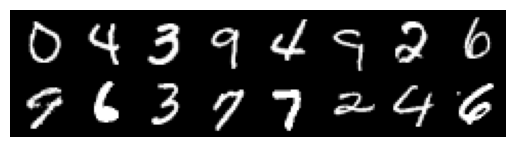

Val samples, 12000


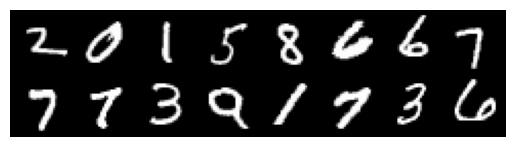

Test samples, 10000


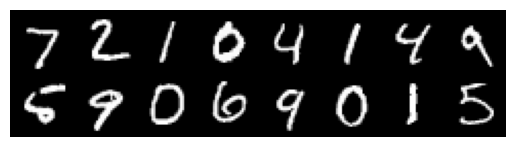

In [43]:
get_data_mnist(batch_size=256, show_image=True, numImages=16);

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train samples, 40000


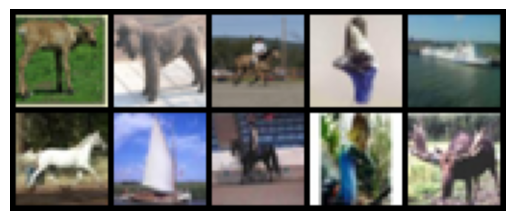

Val samples, 10000


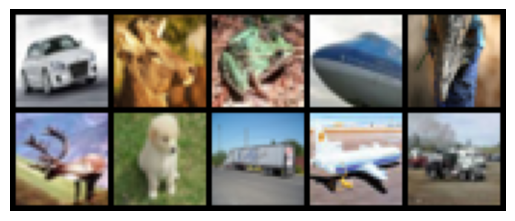

Test samples, 10000


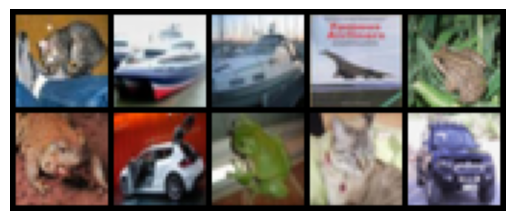

In [44]:
get_data_cifar10(batch_size=256, show_image=True, numImages=10);

# Rede

## Arquitetura

In [51]:
class LeNet(nn.Module) :
    def __init__(self, num_classes=10, in_channels=1):
        super(LeNet, self).__init__()
        self.c1 = nn.Conv2d(in_channels=in_channels, out_channels=6, 
                            kernel_size=(5,5), padding=2, stride=1)
        self.s2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.activationS2 = nn.Sigmoid()
        self.c3 = nn.Conv2d(in_channels=6, out_channels=16, 
                            kernel_size=(5,5), padding=0, stride=1)
        self.s4 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.activationS4 = nn.Sigmoid()
        self.c5 = nn.Conv2d(in_channels=16, out_channels=120, 
                            kernel_size=(5,5), padding=0, stride=2)
        self.activationC5 = nn.Sigmoid()
        self.f6 = nn.Linear(in_features=120, out_features=84)
        self.activationF6 = nn.Tanh()
        self.f = nn.Linear(in_features=84, out_features=num_classes)
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x, debug=False):
        # Convolutional
        if debug : print('Input',x.shape)
        y = self.c1(x)
        if debug : print('Outputs:')
        if debug : print('C1',y.shape)
        y = self.s2(y)
        if debug : print('S2',y.shape)
        y = self.activationS2(y)
        if debug : print('Activation S2',y.shape)
        y = self.c3(y)
        if debug : print('C3',y.shape)
        y = self.s4(y)
        if debug : print('S4',y.shape)
        y = self.activationS4(y)
        if debug : print('Activation S4',y.shape)
        # Flattening
        y = self.c5(y)
        if debug : print('C5',y.shape)
        y = self.activationC5(y)
        if debug : print('Activation C5',y.shape)
        y = y.view(y.shape[0], -1)
        if debug : print('Reshape C5',y.shape)
        # Fully Connected
        y = self.f6(y)
        if debug : print('F6',y.shape)
        y = self.activationF6(y)
        if debug : print('Activation F6',y.shape)
        y = self.f(y)
        if debug : print('F',y.shape)
        s = self.softmax(y)
        if debug : print('Softamx',s.shape)
        return y, s

## Informações sobre a rede

In [52]:
if torch.backends.mps.is_available():
    my_device = torch.device("mps")
elif torch.cuda.is_available():
    my_device = torch.device("cuda:0")
else:
    my_device = torch.device("cpu")
    
print(f"Running on {my_device.type}.")

net = LeNet(num_classes=10, in_channels=3)
net = net.to(my_device)

a = torch.rand( (1, 3, 32, 32) )

b = net( a.to(my_device), debug=True )

Running on mps.
Input torch.Size([1, 3, 32, 32])
Outputs:
C1 torch.Size([1, 6, 32, 32])
S2 torch.Size([1, 6, 16, 16])
Activation S2 torch.Size([1, 6, 16, 16])
C3 torch.Size([1, 16, 12, 12])
S4 torch.Size([1, 16, 6, 6])
Activation S4 torch.Size([1, 16, 6, 6])
C5 torch.Size([1, 120, 1, 1])
Activation C5 torch.Size([1, 120, 1, 1])
Reshape C5 torch.Size([1, 120])
F6 torch.Size([1, 84])
Activation F6 torch.Size([1, 84])
F torch.Size([1, 10])
Softamx torch.Size([1, 10])


In [53]:
print(summary(net, input_size=(1, 3, 28, 28)))

del net, a, b

Layer (type:depth-idx)                   Output Shape              Param #
LeNet                                    [1, 10]                   --
├─Conv2d: 1-1                            [1, 6, 28, 28]            456
├─AvgPool2d: 1-2                         [1, 6, 14, 14]            --
├─Sigmoid: 1-3                           [1, 6, 14, 14]            --
├─Conv2d: 1-4                            [1, 16, 10, 10]           2,416
├─AvgPool2d: 1-5                         [1, 16, 5, 5]             --
├─Sigmoid: 1-6                           [1, 16, 5, 5]             --
├─Conv2d: 1-7                            [1, 120, 1, 1]            48,120
├─Sigmoid: 1-8                           [1, 120, 1, 1]            --
├─Linear: 1-9                            [1, 84]                   10,164
├─Tanh: 1-10                             [1, 84]                   --
├─Linear: 1-11                           [1, 10]                   850
├─Softmax: 1-12                          [1, 10]                   --
To

## Treinamento

In [54]:
def plot_histograms_tensorboard ( writer, net, epoch ) :
    writer.add_histogram('Bias/conv1',   net.c1.bias,        epoch)
    writer.add_histogram('Weight/conv1', net.c1.weight,      epoch)
    writer.add_histogram('Grad/conv1',   net.c1.weight.grad, epoch)

    writer.add_histogram('Bias/conv3',   net.c3.bias,        epoch)
    writer.add_histogram('Weight/conv3', net.c3.weight,      epoch)
    writer.add_histogram('Grad/conv3',   net.c3.weight.grad, epoch)

    writer.add_histogram('Bias/conv5',   net.c5.bias,        epoch)
    writer.add_histogram('Weight/conv5', net.c5.weight,      epoch)
    writer.add_histogram('Grad/conv5',   net.c5.weight.grad, epoch)

In [ ]:
def train ( data_loader, epochs=100, lr=1e-1, prefix='', upper_bound=99.0, device='cpu',
           save=False, debug=False, plot_histograms=False, lambda_reg=0) :

    net = LeNet( data_loader['num_classes'], data_loader['n_channels'] )
    net.to(device)

    optimizer = torch.optim.SGD(net.parameters(), lr, weight_decay=lambda_reg)
    loss = nn.CrossEntropyLoss()

    now = datetime.now()
    suffix = now.strftime("%Y%m%d_%H%M%S")
    prefix = prefix + '-' + suffix if prefix != '' else suffix

    writer = SummaryWriter( log_dir=tensorboard_path+prefix )
    
    writer.add_graph(net, next(iter(data_loader['train']['data']))[0].to(my_device))

    accuracies = []
    max_accuracy = -1.0

    dataset_size = data_loader['train']['length']

    for epoch in tqdm( range(epochs) , desc='Training epochs...' ) :
        net.train()  
        for idx, (train_x, train_label) in enumerate(data_loader['train']['data']):
            train_x = train_x.to(device)
            train_label = train_label.to(device)

            optimizer.zero_grad()

            predict_y = net( train_x )[0]

            # Loss:
            error = loss( predict_y , train_label.long() )

            writer.add_scalar( 'Loss/train', error, 
                            idx+( epoch*(dataset_size//batch_size) ) )

            error.backward()
            optimizer.step()

            # Accuracy:
            predict_ys = torch.max( predict_y, axis=1 )[1]
            correct    = torch.sum(predict_ys == train_label)

            writer.add_scalar( 'Accuracy/train', correct/train_x.size(0)*100, 
                            idx+( epoch*(dataset_size//batch_size) ) )

            if debug and idx % 10 == 0 :
                print(f'idx: {idx}, _error: {error}')

        if plot_histograms : 
            plot_histograms_tensorboard(writer, net, epoch)
        
        accuracy_val, error_val = validate(net, data_loader['val'], device=device, criterion=loss)
        
        accuracies.append(accuracy_val.cpu())
        writer.add_scalar( 'Accuracy/val', accuracy_val, epoch )
    
        if accuracy_val > max_accuracy:
            best_model = copy.deepcopy(net)
            max_accuracy = accuracy_val
            print(f'Saving Best Model with Accuracy: {max_accuracy:3.4f}')
            
        print( f'Epoch: {epoch+1:3d} | Accuracy : {accuracy_val:3.4f}%' )

        if accuracy_val > upper_bound :
            break
   
    if save : 
        path = f'{models_path}-{prefix}-{max_accuracy:.2f}.pkl'
        torch.save(best_model.state_dict(), path)
        print('Model saved in:',path)
  
    plt.plot(accuracies)

    writer.flush()
    writer.close()
    
    return best_model

## Validação

In [56]:
def validate ( model , data , device='cpu', criterion=None, confusion_matrix_labels=None) :
    model.eval()
    correct = 0
    # sum = 0
    error = 0

    label_cm = np.array([])
    predicted_cm = np.array([])
    
    for idx, (test_x, test_label) in enumerate(data['data']) : 
        test_x = test_x.to(device)
        test_label = test_label.to(device)
        predict_y = model( test_x )[0].detach()
        predict_ys = torch.max( predict_y, axis=1 )[1]
        # sum = sum + test_x.size(0)
        correct = correct + torch.sum(predict_ys == test_label)

        if criterion != None:
            error = error + criterion( predict_y , test_label )

        if confusion_matrix_labels != None :
            label_cm = np.concatenate((label_cm, test_label.cpu().numpy()))
            predicted_cm = np.concatenate((predicted_cm, predict_ys.cpu().numpy()))

    accuracy = correct*100./data['length']

    if confusion_matrix_labels != None :

        
        cm = confusion_matrix(
                label_cm, 
                predicted_cm, 
                normalize='true'
            )
        cm = np.round(cm*100, 1)
        disp = ConfusionMatrixDisplay(cm, display_labels=confusion_matrix_labels)
        disp.plot(cmap='Blues')
        plt.title('Normalized Confusion Matrix')
        plt.show()

        cm = confusion_matrix(
                label_cm, 
                predicted_cm, 
            )
        disp = ConfusionMatrixDisplay(cm, display_labels=confusion_matrix_labels)
        disp.plot(cmap='Blues')
        plt.title('Confusion Matrix')
        plt.show()
    
    if criterion == None:
        return accuracy
    else :
        return accuracy, error

# Execução

## Treina

Train samples, 40000


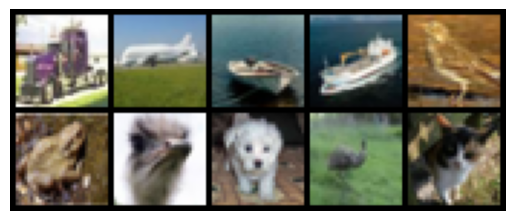

Val samples, 10000


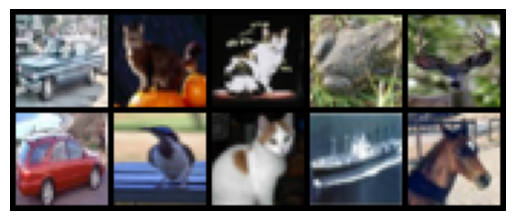

Test samples, 10000


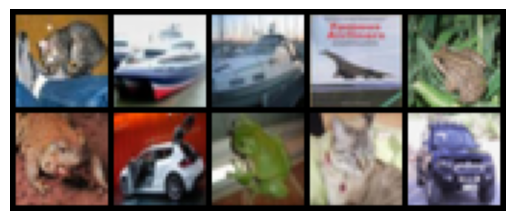

In [57]:
if torch.backends.mps.is_available():
    my_device = torch.device("mps")
elif torch.cuda.is_available():
    my_device = torch.device("cuda:0")
else:
    my_device = torch.device("cpu")

epochs = 10
dataset = 'cifar10' 
#dataset = 'mnist' 
lr = 1.3e0
lambda_reg = 0

if dataset == 'mnist' :
    batch_size = 256
    data_loader = get_data_mnist(batch_size, show_image=True)
elif dataset == 'cifar10' :
    batch_size = 256
    data_loader = get_data_cifar10(batch_size, show_image=True)
else :
    print('Dataset loader not implemented.')
    

prefix = 'LeNet-{}-e-{}-lr-{}'.format(dataset, epochs, lr)

Running on mps.


Training epochs...:  10%|█         | 1/10 [00:05<00:45,  5.08s/it]

Saving Best Model with Accuracy: 9.8900
Epoch:   1 | Accuracy : 9.8900%


Training epochs...:  20%|██        | 2/10 [00:09<00:38,  4.81s/it]

Saving Best Model with Accuracy: 17.8000
Epoch:   2 | Accuracy : 17.8000%


...

Saving Best Model with Accuracy: 36.5800
Epoch:   8 | Accuracy : 36.5800%


Training epochs...:  90%|█████████ | 9/10 [00:45<00:05,  5.17s/it]

Epoch:   9 | Accuracy : 33.7500%


Training epochs...: 100%|██████████| 10/10 [00:50<00:00,  5.07s/it]

Saving Best Model with Accuracy: 36.9100
Epoch:  10 | Accuracy : 36.9100%
Model saved in: /Users/nicholasbarbosa/Mestrado/inf692/atividade-curta-5/models/-LeNet-cifar10-e-10-lr-1.3-20260507_220905-36.91.pkl


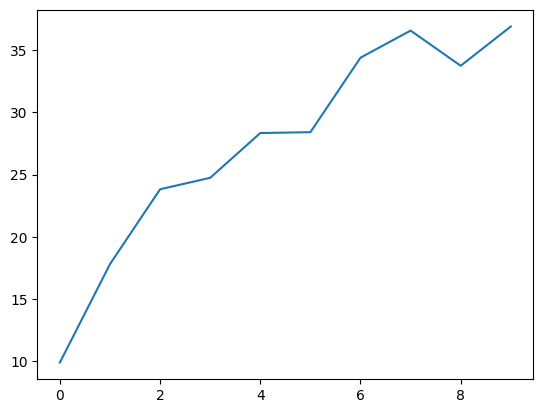

In [58]:
print(f"Running on {my_device.type}.")

net = train( data_loader=data_loader, epochs=epochs, lr=lr, prefix=prefix , upper_bound=100, device=my_device,
            save=True, debug=False, plot_histograms=True, lambda_reg=lambda_reg )

# Carregar Rede de arquivo

In [ ]:
del net

path = '/Users/nicholasbarbosa/Mestrado/inf692/atividade-curta-5/models/-LeNet-cifar10-e-10-lr-1.3-20260507_215512-38.55.pkl'
n_channels = 3

if torch.cuda.is_available():
    my_device = torch.device("cuda:0")
else:
    my_device = torch.device("cpu")


def load_LeNet ( device , path ) :
    net = LeNet(num_classes=10, in_channels=n_channels)
    net = net.to(device)
    net.load_state_dict(torch.load(path))
    net.eval()
    return net

net = load_LeNet(my_device, path)

# Carregar dado do MNIST e inferir

Sample: 8149


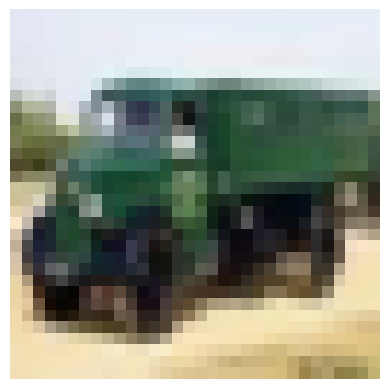


Predicted clas: 9 
Classifier confidence: 51.46% 
True label: 9


In [63]:
def sample_and_predict ( data_loader ) :

    test_dataset = data_loader['test']['data'].dataset
    idx = np.random.randint(0, len(test_dataset) - 1)
    img, label = test_dataset[idx]
    
    x = img.unsqueeze_(0)

    x = x.to(my_device)

    y = net ( x )[1]
    confidence = torch.max(y, 1)[0]
    prediction = torch.max(y, 1)[1]

    print( 'Sample: {}'.format(idx) )
    
    img = img.squeeze_(0)

    if dataset=='cifar10':

        img_show = img * 0.5 + 0.5
        plt.imshow(img_show.permute(1, 2, 0))
    else :
        img_show = img.squeeze()  
        img_show = img_show * 0.5 + 0.5
        
        plt.imshow(img_show, cmap='gray')
        
    plt.axis('off')
    plt.show()

    confidence = confidence.data.cpu().numpy()[0]
    prediction = prediction.data.cpu().numpy()[0]

    return prediction, confidence, label

prediction, confidence, label = sample_and_predict(data_loader)
print( f'\nPredicted clas: {prediction} \nClassifier confidence: {confidence*100:4.2f}% \nTrue label: {label}' )


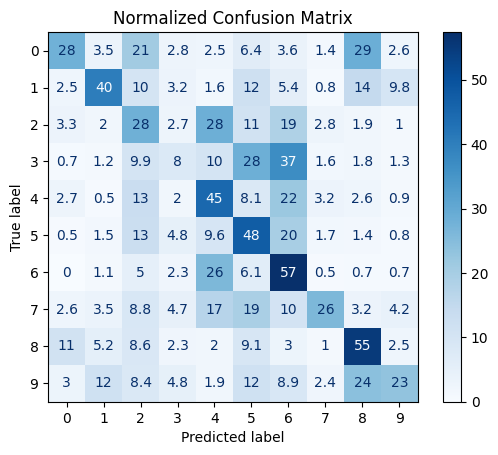

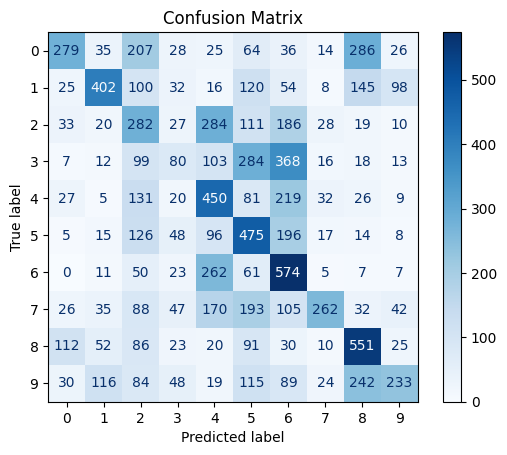

A acurácia do modelo treinado no conjunto de teste é: 35.88% 


In [62]:
accuracy_test = validate ( net , 
                          data_loader['test'] , 
                          device=my_device, 
                          confusion_matrix_labels=['0','1','2','3','4','5','6','7','8','9']
                         )
print(f"A acurácia do modelo treinado no conjunto de teste é: {accuracy_test:.2f}% ")